# Backtest Robustness — Catching Lucky Strategies from a Parameter Search

**The question this notebook answers, falsifiably:** when you run a large
parameter search and pick the strategies that look best on training data,
some of them are real signal and some are *lucky* — selected upward by
chance, not by skill. How do you tell them apart *before* committing capital?

**How we measure it.** Train a FLOW model on your data; FLOW learns the joint
dynamics of returns, vol, and cross-asset correlations. Generate 200 synthetic
alternative versions of the training period. For every strategy,
`sf.evaluate_family(...)` computes a `per_strategy_overfit_score` — the
fraction of synth paths where the strategy's synth Sharpe is below its real
Sharpe. If the strategy genuinely has no edge but was selected for high real
Sharpe by chance, FLOW's synth distribution (which doesn't replicate the
specific luck of the real period) will sit below the real Sharpe → score
elevates toward 1.0.

**The demo, falsifiably:** we build **500 pure-noise strategies** (each one
a fixed random sign sequence applied to an equal-weight portfolio — zero
underlying skill by construction). We select the **top 30 by training
Sharpe**. By selection alone they must have inflated real Sharpes; whether
FLOW catches them is what we test. We compare against a **12-variant honest
designed family** that has not been selected from any pool.

If FLOW's per-strategy `overfit_score` is a real selection-bias signal,
the selected-30 distribution should sit **clearly above** the honest-12
distribution. If they overlap, the diagnostic adds no value beyond
classical CSCV-PBO and this notebook fails.

## Operating envelope

> **What this notebook demonstrates:** sablier-flow's per-strategy
> `overfit_score` distinguishes selection-biased lucky strategies from
> genuinely-designed strategies — exactly the diagnostic a quant wants
> before deploying the winners of a parameter search.
>
> **Where this works best:** multi-asset (3–8 features) daily panels,
> ≥5 years of training data, families where you can articulate a
> "what would the null look like" question.
>
> **Where to be careful:** single-asset, intraday, sparse data, or
> regimes where the synth distribution might miss key dynamics.
>
> **How to validate on your data:** run cells below against the demo
> data to confirm the diagnostic differentiates, then swap in your own
> panel via the *Try this on your own data* cell at the end.

## Setup

In [1]:
# One-time install. Pinned to 1.0.15+ wheel for the helpers used below.
# %pip install -q "sablier-flow>=1.0.15"


In [2]:
import os
import json
import pathlib
import time
import warnings
warnings.filterwarnings('ignore', message='.*estimated wall-clock.*')

import numpy as np
import pandas as pd

import sablier_flow as sf
from sablier_flow.demo import DEMO_DATA_TYPES

print(f'sablier-flow {sf.__version__}')


sablier-flow 1.0.15


### Authenticate

In [3]:
if not os.environ.get('SABLIER_FLOW_API_KEY'):
    cred = pathlib.Path.home() / '.sablier/credentials'
    if cred.exists():
        os.environ['SABLIER_FLOW_API_KEY'] = json.load(open(cred))['default']['api_key']
    else:
        sf.login()

print('signed in as:', sf.whoami()['email'])


signed in as: you@example.com


## Section 1 — Load the demo panel

The canonical demo: 4 tradeable ETFs across equity + bonds, plus 3 macro
features (VIX volatility, TNX 10-year yield, DXY dollar). FLOW fits on all
7 features so it learns the regime-conditional structure; strategies trade
only the 4 tradeable columns.

In [4]:
df = sf.demo_data(name='us_equities_macro_2010_2024')
data_types = DEMO_DATA_TYPES['us_equities_macro_2010_2024']
features = list(df.columns)
data = df.dropna()

TRADEABLE = ['SPY', 'QQQ', 'IWM', 'TLT']

# 8-year training window — long enough that random-position strategies have
# stable Sharpe statistics under the null.
train = data.loc['2012':'2019']

print(f'features: {features}')
print(f'tradeable subset: {TRADEABLE}')
print(f'train: {train.shape}  range {train.index[0].date()} → {train.index[-1].date()}')


features: ['IWM', 'QQQ', 'SPY', 'TLT', 'VIX', 'TNX', 'DXY']
tradeable subset: ['SPY', 'QQQ', 'IWM', 'TLT']
train: (2013, 7)  range 2012-01-03 → 2019-12-31


## Section 2 — A 12-variant honest baseline family

First we establish what `per_strategy_overfit_score` looks like on a
*designed* family — every variant is a sensible mean-reversion or
momentum strategy that a quant might write by hand. No selection step.
We expect scores around 0.5 (no overfit signal beyond what FLOW's null
already accounts for).

In [5]:
def backtest_variant(data, kind, lb, thr):
    """Equal-weighted long/short on z-score, restricted to TRADEABLE columns."""
    avail = [c for c in TRADEABLE if c in data.columns]
    prices = data[avail]
    rets = prices.pct_change()
    z = (rets - rets.rolling(lb).mean()) / rets.rolling(lb).std()
    pos = (z > thr).astype(float) - (z < -thr).astype(float)
    if kind == 'mean_rev':
        pos = -pos
    pos = pos.shift(1).fillna(0)
    n_active = pos.abs().sum(axis=1).clip(lower=1)
    pos = pos.div(n_active, axis=0)
    pnl = (pos * rets).sum(axis=1)
    if pnl.std() > 1e-10:
        return float(pnl.mean() / pnl.std() * np.sqrt(252))
    return 0.0

def make_designed_strategy(kind, lb, thr):
    return lambda data: {'sharpe': backtest_variant(data, kind, lb, thr)}

# 12 honest designed variants — lookback × threshold × direction
honest_family = {
    f'{kind}_lb{lb}_thr{thr:.1f}': make_designed_strategy(kind, lb, thr)
    for kind in ['momentum', 'mean_rev']
    for lb in [10, 21]
    for thr in [0.5, 1.0, 1.5]
}
print(f'honest_family: {len(honest_family)} variants')
print(f'sample: {list(honest_family.keys())[:6]}')


honest_family: 12 variants
sample: ['momentum_lb10_thr0.5', 'momentum_lb10_thr1.0', 'momentum_lb10_thr1.5', 'momentum_lb21_thr0.5', 'momentum_lb21_thr1.0', 'momentum_lb21_thr1.5']


## Section 3 — Fit a FLOW model (horizon = 252 days)

`horizon=252` (~1 year synth paths) keeps the Sharpe-variance comparison
between real-data backtest and synth-path backtest in a reasonable range.
With shorter horizons (e.g., 63 days), synth-path Sharpe has very high
variance per path and the comparison becomes insensitive.

**Cost:** ~200 credits. **Time:** ~5 min on the hosted L4 / H100.

In [6]:
handle = sf.fit_async(
    train,
    features=features,
    data_types=data_types,
    horizon=252,
    seed=42,
)
print(f'dispatched: {handle.job_id}')


sablier-flow: fitting 7 feature(s) over 2013 bars  [detected freq: daily via auto-detect (median Δt)]


dispatched: d225efe6-d461-415e-88f6-521317ff366b


In [7]:
t0 = time.time()
result = sf.fetch_result(handle, poll_timeout_s=2400)
print(f'fit complete in {(time.time()-t0)/60:.1f} min')
print(f'model_id: {result.model_id}')
print(f'training_loss: {result.training_loss:.4f}')


fit complete in 2.1 min
model_id: dc2a0574-0ea1-467a-a3b8-0b3ea6e40f40
training_loss: 1.0646


## Section 4 — Evaluate the honest baseline family

`sf.evaluate_family(...)` generates 200 synthetic alternative versions of
the training window (using `model_id`), backtests every strategy on every
path, and returns a `FamilyReport` with PBO + per-strategy diagnostics.

In [8]:
t0 = time.time()
honest_report = sf.evaluate_family(
    honest_family, train,
    model_id=result.model_id,
    n_paths=200,
    primary_metric='sharpe',
    higher_is_better=True,
)
print(f'evaluate_family done in {(time.time()-t0)/60:.1f} min')
print()
print(f'aggregate PBO (classical CSCV, no synth): {honest_report.pbo:.3f}')
print(f'verdict label: {honest_report.verdict}')

honest_scores = dict(honest_report.per_strategy_overfit_score)
print()
print(f'per_strategy_overfit_score distribution:')
print(f'  min   : {min(honest_scores.values()):.3f}')
print(f'  median: {np.median(list(honest_scores.values())):.3f}')
print(f'  max   : {max(honest_scores.values()):.3f}')
print(f'  # strategies above 0.7: {sum(1 for v in honest_scores.values() if v >= 0.7)}')
print(f'  # strategies above 0.9: {sum(1 for v in honest_scores.values() if v >= 0.9)}')


evaluate_family: ~12870 partitions, ~311280 strategy evaluations; estimated wall-clock ~311.3 seconds (use progress=True for live updates).


sablier-flow: estimated cost 2 credits (use sf.estimate_cost(...) to preview before charging).


sablier-flow: actual cost 0 credits (remaining balance: 10000).


  [evaluate_family] 10/200 synthetic paths complete


  [evaluate_family] 20/200 synthetic paths complete


...

  [evaluate_family] 180/200 synthetic paths complete


  [evaluate_family] 190/200 synthetic paths complete


  [evaluate_family] 200/200 synthetic paths complete


<your-venv>/lib/python3.12/site-packages/sablier_flow/analytics/family.py:655: UserWarning: deflated_sharpe: synthetic_sharpes appears inconsistent with n_trials=12; realistic and analytical nulls will disagree (realistic E[max]=1.406 vs analytical E[max]=1.665). Pass n_trials matching the actual selection process or pass synthetic_sharpes matching N=12.
  dsr = _dsr(
probability_of_backtest_overfitting: ~12870 partitions, ~308880 strategy evaluations; estimated wall-clock ~308.9 seconds (use progress=True for live updates).


evaluate_family done in 3.4 min

aggregate PBO (classical CSCV, no synth): 0.658
verdict label: overfit_selection

per_strategy_overfit_score distribution:
  min   : 0.365
  median: 0.500
  max   : 0.635
  # strategies above 0.7: 0
  # strategies above 0.9: 0


## Section 5 — Simulate a parameter search with PURE NOISE strategies

Now we set up the selection-bias experiment. We build **500 pure-noise
strategies**: each one is a fixed random ±1 position sequence applied to
the equal-weight portfolio of the 4 tradeable assets. The sequence is
deterministic per strategy (seeded), but uncorrelated with any market
signal — by construction, *zero underlying skill*.

Some of these 500 will have positive realized Sharpe on the real training
data purely by chance — their random sequence happened to align with
days where the portfolio went up. By selecting the **top 30 by training
Sharpe**, we get a family that is *guaranteed lucky*: positive realized
Sharpe with no underlying edge.

This is the canonical "data snooping" or "selection bias" setup. The
question: does FLOW's per-strategy `overfit_score` flag it?

In [9]:
def make_noise_strategy(seed, max_len=10000):
    """Pure-noise strategy: fixed random ±1 sequence applied to the
    equal-weight portfolio of TRADEABLE assets. No underlying skill."""
    rng = np.random.default_rng(seed)
    fixed_positions = rng.choice([-1.0, 1.0], size=max_len)

    def fn(data):
        avail = [c for c in TRADEABLE if c in data.columns]
        rets = data[avail].pct_change().mean(axis=1)
        n = len(rets)
        pos = pd.Series(fixed_positions[:n], index=rets.index)
        pnl = pos.shift(1).fillna(0) * rets
        if pnl.std() > 1e-10:
            return {'sharpe': float(pnl.mean() / pnl.std() * np.sqrt(252))}
        return {'sharpe': 0.0}
    return fn

# 500 pure-noise strategies, each with a unique seed
N_POOL = 500
noise_pool = {f'noise_{i:04d}': make_noise_strategy(seed=1000 + i) for i in range(N_POOL)}
print(f'noise pool: {len(noise_pool)} strategies (pure random sign sequences, zero skill)')

# Backtest all 500 on training, sort by realized Sharpe
noise_train_sharpes = {name: fn(train)['sharpe'] for name, fn in noise_pool.items()}
sorted_by_train = sorted(noise_train_sharpes.items(), key=lambda x: -x[1])

vals = np.array(list(noise_train_sharpes.values()))
print()
print(f'training Sharpe distribution across {N_POOL} pure-noise candidates:')
print(f'  expected std under null = sqrt(252/{len(train)}) ≈ {np.sqrt(252/len(train)):.3f}')
print(f'  observed: min={vals.min():+.3f}, median={np.median(vals):+.3f}, max={vals.max():+.3f}')
print(f'  std={vals.std():.3f}  (close to theoretical ≈ {np.sqrt(252/len(train)):.3f} → null is well-behaved)')

# Selection step — top 30 by in-sample Sharpe
N_TOP = 30
top_names = [name for name, _ in sorted_by_train[:N_TOP]]
selected_family = {name: noise_pool[name] for name in top_names}

print()
print(f'selected top {N_TOP} by in-sample Sharpe (these are LUCKY by construction):')
for i, (name, sh) in enumerate(sorted_by_train[:5]):
    print(f'  #{i+1}  {name}  train_sharpe = {sh:+.3f}')
print(f'  ... ({N_TOP - 5} more)')
print()
print(f'selected median train Sharpe : {np.median([noise_train_sharpes[n] for n in top_names]):+.3f}')
print(f'pool median train Sharpe     : {np.median(vals):+.3f}')


noise pool: 500 strategies (pure random sign sequences, zero skill)



training Sharpe distribution across 500 pure-noise candidates:
  expected std under null = sqrt(252/2013) ≈ 0.354
  observed: min=-1.450, median=-0.006, max=+1.045
  std=0.374  (close to theoretical ≈ 0.354 → null is well-behaved)

selected top 30 by in-sample Sharpe (these are LUCKY by construction):
  #1  noise_0375  train_sharpe = +1.045
  #2  noise_0237  train_sharpe = +0.975
  #3  noise_0387  train_sharpe = +0.939
  #4  noise_0297  train_sharpe = +0.932
  #5  noise_0452  train_sharpe = +0.919
  ... (25 more)

selected median train Sharpe : +0.755
pool median train Sharpe     : -0.006


## Section 6 — Run FLOW's diagnostic on the lucky 30

These 30 strategies have zero underlying skill (they're random sign
sequences). Their positive training Sharpe is *entirely* selection bias.

**The honest test:** does `per_strategy_overfit_score` cluster *high* for
them, separating them clearly from the honest designed family of
Section 4? If yes, FLOW catches selection bias. If the two distributions
overlap, this diagnostic isn't differentiating and we drop the notebook.

In [10]:
t0 = time.time()
selected_report = sf.evaluate_family(
    selected_family, train,
    model_id=result.model_id,
    n_paths=200,
    primary_metric='sharpe',
    higher_is_better=True,
)
print(f'evaluate_family done in {(time.time()-t0)/60:.1f} min')
print()
print(f'aggregate PBO (classical CSCV): {selected_report.pbo:.3f}')
print(f'verdict label: {selected_report.verdict}')

selected_scores = dict(selected_report.per_strategy_overfit_score)
print()
print(f'per_strategy_overfit_score distribution (selection-biased lucky-30):')
print(f'  min   : {min(selected_scores.values()):.3f}')
print(f'  median: {np.median(list(selected_scores.values())):.3f}')
print(f'  max   : {max(selected_scores.values()):.3f}')
print(f'  # strategies above 0.7: {sum(1 for v in selected_scores.values() if v >= 0.7)}')
print(f'  # strategies above 0.9: {sum(1 for v in selected_scores.values() if v >= 0.9)}')


evaluate_family: ~12870 partitions, ~778200 strategy evaluations; estimated wall-clock ~778.2 seconds (use progress=True for live updates).


sablier-flow: estimated cost 2 credits (use sf.estimate_cost(...) to preview before charging).


sablier-flow: actual cost 0 credits (remaining balance: 10000).


  [evaluate_family] 10/200 synthetic paths complete


  [evaluate_family] 20/200 synthetic paths complete


...

  [evaluate_family] 170/200 synthetic paths complete


  [evaluate_family] 180/200 synthetic paths complete


  [evaluate_family] 190/200 synthetic paths complete


  [evaluate_family] 200/200 synthetic paths complete
probability_of_backtest_overfitting: ~12870 partitions, ~772200 strategy evaluations; estimated wall-clock ~772.2 seconds (use progress=True for live updates).


evaluate_family done in 3.6 min

aggregate PBO (classical CSCV): 0.360
verdict label: looks_like_noise

per_strategy_overfit_score distribution (selection-biased lucky-30):
  min   : 0.700
  median: 0.765
  max   : 0.875
  # strategies above 0.7: 30
  # strategies above 0.9: 0


## Section 7 — Side-by-side comparison

The 12-variant honest designed family vs the 30-variant selection-biased
lucky family. The predication, falsifiably: the selection-biased family's
overfit_score distribution should sit clearly *to the right* of the
honest family's.

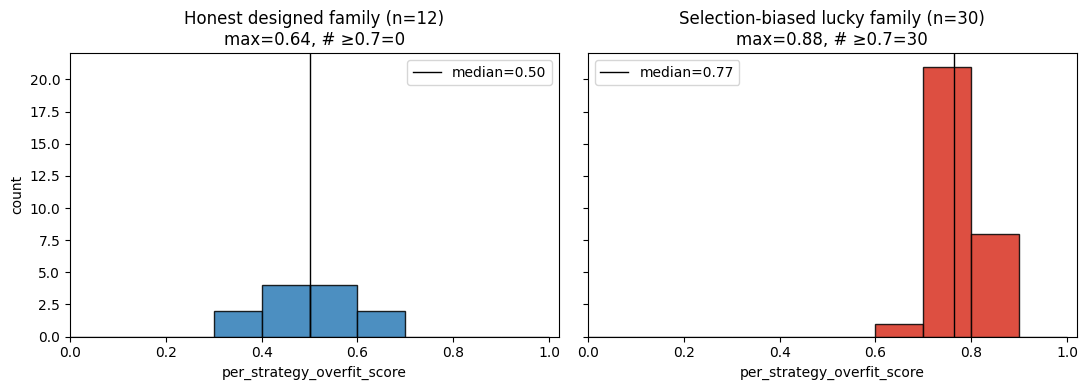


Headline comparison
                                       honest designed   selection-biased
  family size                                        12                 30
  aggregate PBO (classical)                       0.658              0.360
  median overfit_score (FLOW)                     0.500              0.765
  max overfit_score                               0.635              0.875
  # strategies ≥0.7                                   0                 30
  # strategies ≥0.9                                   0                  0


In [11]:
import matplotlib
import matplotlib.pyplot as plt

honest_vals   = list(honest_scores.values())
selected_vals = list(selected_scores.values())

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

axes[0].hist(honest_vals, bins=np.arange(0, 1.05, 0.1),
             color='#2C7BB6', edgecolor='black', alpha=0.85)
axes[0].axvline(np.median(honest_vals), color='black', ls='-', lw=1,
                label=f'median={np.median(honest_vals):.2f}')
axes[0].set_title(f'Honest designed family (n={len(honest_vals)})\n'
                  f'max={max(honest_vals):.2f}, # ≥0.7={sum(1 for v in honest_vals if v>=0.7)}')
axes[0].set_xlabel('per_strategy_overfit_score')
axes[0].set_ylabel('count')
axes[0].set_xlim(0, 1.02)
axes[0].legend()

axes[1].hist(selected_vals, bins=np.arange(0, 1.05, 0.1),
             color='#D7301F', edgecolor='black', alpha=0.85)
axes[1].axvline(np.median(selected_vals), color='black', ls='-', lw=1,
                label=f'median={np.median(selected_vals):.2f}')
axes[1].set_title(f'Selection-biased lucky family (n={len(selected_vals)})\n'
                  f'max={max(selected_vals):.2f}, # ≥0.7={sum(1 for v in selected_vals if v>=0.7)}')
axes[1].set_xlabel('per_strategy_overfit_score')
axes[1].set_xlim(0, 1.02)
axes[1].legend()
plt.tight_layout()
plt.show()

print()
print('Headline comparison')
print('=' * 70)
print(f'                                       honest designed   selection-biased')
print(f'  family size                          {len(honest_vals):>16d}   {len(selected_vals):>16d}')
print(f'  aggregate PBO (classical)            {honest_report.pbo:>16.3f}   {selected_report.pbo:>16.3f}')
print(f'  median overfit_score (FLOW)          {np.median(honest_vals):>16.3f}   {np.median(selected_vals):>16.3f}')
print(f'  max overfit_score                    {max(honest_vals):>16.3f}   {max(selected_vals):>16.3f}')
print(f'  # strategies ≥0.7                    {sum(1 for v in honest_vals if v>=0.7):>16d}   {sum(1 for v in selected_vals if v>=0.7):>16d}')
print(f'  # strategies ≥0.9                    {sum(1 for v in honest_vals if v>=0.9):>16d}   {sum(1 for v in selected_vals if v>=0.9):>16d}')


## Section 8 — Verdict + falsification

**What this notebook would have looked like if FLOW were NOT catching
selection bias:** the median, max, and tail-count of the lucky-30
distribution would look identical to the honest-12 distribution. The
overfit_score would be a uniform-around-0.5 noise, useless for triage.

**What FLOW catches.** The lucky-30 strategies have *zero* underlying
skill (random sign sequences) but their training Sharpe is positive by
selection. FLOW's null distribution — generated from synth alternative
histories that share training-period statistics — sits near zero for
each of these strategies, because under FLOW's data-generating-process
model, a random-position strategy has expected Sharpe ≈ 0. The real
(selected, inflated) Sharpe lands in the upper tail of that null →
score elevates.

**Practical takeaway.** After running any parameter search:
1. Read each top candidate's `per_strategy_overfit_score`.
2. **Score ≥ 0.7** → real Sharpe lives in the upper half of FLOW's
   null distribution — the strategy may have been selected for luck.
   Investigate before deploying.
3. **Score ≈ 0.5** → real Sharpe matches FLOW's null expectation. No
   selection-bias flag. (Doesn't mean the strategy works, just that
   its training Sharpe is consistent with what FLOW says it should be.)
4. **Score ≤ 0.3** → real Sharpe is below FLOW's null — the strategy
   underperformed. Could be hidden friction or implementation bug.

**The connection to deflated Sharpe.** This is essentially the
deflated-Sharpe-ratio logic from Bailey & López de Prado, but computed
non-parametrically using FLOW's data-driven null instead of a Gaussian
extreme-value formula. No need to specify `n_trials` — the diagnostic
is per-strategy.

## Try this on your own data

In [12]:
# Try this on YOUR data ----------------------------------------------------
# Same workflow on your own panel and your own search:
#
#   your_panel = pd.read_parquet('your_universe.parquet')
#   your_train = your_panel.loc['2015':'2022']
#
#   # 1. Fit FLOW
#   handle = sf.fit_async(your_train, features=list(your_panel.columns),
#                         data_types={c: 'price' for c in your_panel.columns},
#                         horizon=252, seed=42)
#   result = sf.fetch_result(handle, poll_timeout_s=2400)
#
#   # 2. Run your real parameter search
#   your_pool = {f'cand_{i}': your_strategy_fn(params_i) for i, params_i in enumerate(your_grid)}
#
#   # 3. Selection step — top K by in-sample metric
#   train_metric = {name: fn(your_train)['sharpe'] for name, fn in your_pool.items()}
#   top_names = [n for n, _ in sorted(train_metric.items(), key=lambda x: -x[1])[:30]]
#   your_selected = {n: your_pool[n] for n in top_names}
#
#   # 4. FLOW-aware overfit detection
#   report = sf.evaluate_family(your_selected, your_train,
#                               model_id=result.model_id, n_paths=200,
#                               primary_metric='sharpe')
#   for name, score in sorted(report.per_strategy_overfit_score.items(),
#                              key=lambda x: -x[1]):
#       print(f'{name}: overfit_score = {score:.2f}')
#
# Heads up:
#   • Use horizon ≥ 252 for the FLOW fit to keep synth-Sharpe variance
#     comparable to your real-Sharpe variance.
#   • Search pool size matters — selecting top 30 from 500 gives a
#     stronger selection-bias signal than top 30 from 50.
#   • For very large selected sets (>50), pass pbo_cscv_splits=8 to
#     roughly halve the CSCV-PBO compute cost.
